# Computer Exercise 12.1 — Problem 3

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 12. Partial Differential Equations · **절**: §12.1 Parabolic Problems (Heat Equation)
> **주제**: **Crank–Nicolson** — 무조건 안정 + 시간 2차. 세 방법의 **수렴차수** 비교
> **풀이 일자**: 2026-06-15 · **언어**: 한국어(본문) / English(그래프 라벨)

## 1. 문제 (원문)

> Implement the **Crank–Nicolson** scheme for the heat equation $u_t=\alpha u_{xx}$ (same IC/BC as before) by averaging the explicit and implicit centered-difference
> operators (the trapezoidal rule in time). Show that it is **unconditionally stable**
> and **second-order in both time and space**, $\mathcal{O}(\Delta t^2)+\mathcal{O}(\Delta x^2)$.
> Then, refining $\Delta t$ and $\Delta x$ together, **measure and compare the temporal
> order of accuracy** of the explicit (FTCS), implicit (BTCS), and Crank–Nicolson methods.

### 한국어 풀이용 정리
문제 1(양함수)은 *조건부 안정 + 시간 1차*, 문제 2(음함수)는 *무조건 안정 + 시간 1차* 였다. 둘을 **시간방향 사다리꼴(평균)** 로 묶은 것이 **Crank–Nicolson**: 양함수와 음함수의 공간연산자를 반반 섞어 *무조건 안정* 을 유지하면서 시간 절단오차를 $\mathcal{O}(\Delta t^2)$ 로 끌어올린다. 마지막으로 세 방법의 수렴차수를 log-log 로 실측해 §12.1 을 마무리한다.

## 2. 수학적 배경

### 2.1 Crank–Nicolson 이산화
공간 2계차분 연산자 $\delta_x^2 u_i = u_{i-1}-2u_i+u_{i+1}$ 를 *옛 층과 새 층의 평균* 으로:

$$ \frac{u_i^{n+1}-u_i^{n}}{\Delta t}=\frac{\alpha}{2\Delta x^2}\big(\delta_x^2 u_i^{n+1}+\delta_x^2 u_i^{n}\big). $$

$r=\alpha\Delta t/\Delta x^2$ 로 정리하면 (좌변 = 새 층, 우변 = 옛 층)

$$ \boxed{\; -\tfrac{r}{2}u_{i-1}^{n+1}+(1+r)u_i^{n+1}-\tfrac{r}{2}u_{i+1}^{n+1}=\tfrac{r}{2}u_{i-1}^{n}+(1-r)u_i^{n}+\tfrac{r}{2}u_{i+1}^{n}. \;}$$

좌변은 삼중대각 $A=\mathrm{tri}(-\tfrac r2,\,1+r,\,-\tfrac r2)$, 우변은 $B=\mathrm{tri}(\tfrac r2,\,1-r,\,\tfrac r2)$. 매 층 $A\mathbf{u}^{n+1}=B\mathbf{u}^{n}$.

### 2.2 안정성과 정확도
증폭인자

$$ \xi(k)=\frac{1-2r\sin^2(k\Delta x/2)}{1+2r\sin^2(k\Delta x/2)},\qquad |\xi|\le1\ \forall r>0 $$

이므로 **무조건 안정**. 시간 사다리꼴이라 절단오차는

$$ \boxed{\; \mathcal{O}(\Delta t^2)+\mathcal{O}(\Delta x^2) \;}$$

— 시간·공간 모두 **2차**. 세 방법의 시간차수 요약: FTCS 1차(조건부), BTCS 1차(무조건), CN 2차(무조건).

## 3. 풀이 흐름

1. 삼중대각 $A,B$ 를 $r$ 로 조립하고 매 층 $A\mathbf{u}^{n+1}=B\mathbf{u}^{n}$ 풀이 함수 작성.
2. 큰 $r$ 에서도 안정함을 정확해와 비교해 먼저 확인.
3. **시간차수 실측**: 공간격자를 매우 촘촘히 고정($M$ 크게)해 공간오차를 무시할 수준으로 낮춘 뒤, $\Delta t$ 만 반씩 줄이며 최종시간 오차를 측정.
4. FTCS·BTCS·CN 각각에 대해 $\text{error vs }\Delta t$ 의 log-log 기울기로 **시간차수** 추정.
5. 표: $\Delta t$ 별 세 방법 오차 + 각 방법의 차수 추정치.
6. 시각화: (좌) CN 해 vs 정확해, (우) 세 방법의 $\Delta t$-수렴 log-log (기울기 1 vs 1 vs 2).
7. 결론 — CN 의 우월성과 한계(큰 $r$ 에서의 진동), §12.1 마무리 및 Ch 12 다음 절 예고.

In [1]:
%matplotlib inline

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.float_format", lambda v: f"{v:.6e}")

alpha = 1.0
def u0(x):       return np.sin(np.pi*x)
def exact(x, t): return np.exp(-alpha*np.pi**2*t)*np.sin(np.pi*x)

def _tri(m, lo, di, up):
    return (np.diag(di*np.ones(m)) + np.diag(up*np.ones(m-1), 1)
            + np.diag(lo*np.ones(m-1), -1))

def step_solver(M, dt, T, scheme):
    """scheme in {'ftcs','btcs','cn'}. 동차 Dirichlet, IC=sin(pi x). 최종 (x,u) 반환."""
    dx = 1.0/M; r = alpha*dt/dx**2; ns = int(round(T/dt)); m = M-1
    x = np.linspace(0,1,M+1); u = u0(x)
    if scheme == 'btcs':
        A = _tri(m, -r, 1+2*r, -r)
    elif scheme == 'cn':
        A = _tri(m, -r/2, 1+r, -r/2); B = _tri(m, r/2, 1-r, r/2)
    for _ in range(ns):
        if scheme == 'ftcs':
            un = u.copy()
            u[1:-1] = un[1:-1] + r*(un[:-2]-2*un[1:-1]+un[2:])
        elif scheme == 'btcs':
            u[1:-1] = np.linalg.solve(A, u[1:-1])
        else:  # cn
            u[1:-1] = np.linalg.solve(A, B @ u[1:-1])
        u[0]=u[-1]=0.0
    return x, u, r, ns

# CN 무조건 안정 확인 (큰 r)
M, T = 40, 0.05
for r in [0.5, 5.0, 50.0]:
    dt = r*(1.0/M)**2/alpha
    xx, uu, rr, ns = step_solver(M, dt, T, 'cn')
    err = np.max(np.abs(uu - exact(xx, T)))
    print(f"CN r={r:5.1f}: steps={ns:4d}, max|u|={np.max(np.abs(uu)):.4e}, max_error={err:.4e}")

CN r=  0.5: steps= 160, max|u|=6.1065e-01, max_error=1.5461e-04
CN r=  5.0: steps=  16, max|u|=6.1063e-01, max_error=1.3100e-04
CN r= 50.0: steps=   2, max|u|=5.3715e-01, max_error=7.3353e-02


In [3]:
# --- CN 격자점별 수치해 vs 정확해 (r=5) ---
dt5 = 5.0*(1.0/M)**2/alpha
x_c, u_c, _, _ = step_solver(M, dt5, T, 'cn')
ue = exact(x_c, T)
tbl = pd.DataFrame({"x": x_c, "u_cn": u_c, "u_exact": ue, "abs_error": np.abs(u_c-ue)})
tbl.iloc[::4]

,x,u_cn,u_exact,abs_error
0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
4,1.000000e-01,1.886947e-01,1.886543e-01,4.048069e-05
8,2.000000e-01,3.589187e-01,3.588417e-01,7.699885e-05
12,3.000000e-01,4.940093e-01,4.939033e-01,1.059798e-04
16,4.000000e-01,5.807427e-01,5.806181e-01,1.245868e-04
20,5.000000e-01,6.106290e-01,6.104980e-01,1.309983e-04
24,6.000000e-01,5.807427e-01,5.806181e-01,1.245868e-04
28,7.000000e-01,4.940093e-01,4.939033e-01,1.059798e-04
32,8.000000e-01,3.589187e-01,3.588417e-01,7.699885e-05
36,9.000000e-01,1.886947e-01,1.886543e-01,4.048069e-05


In [4]:
# --- 시간차수 실측 (핵심: '공간오차'를 빼고 '시간오차'만 측정) ---
# 정확해(PDE)와 비교하면 공간 절단오차 O(dx^2) 가 바닥(floor)을 만들어 dt 를 줄여도
# 더 안 줄어든다(차수 측정 불가). 그래서 *같은 공간격자에서* 각 방법이 매우 작은 dt 로
# 수렴한 자기 자신을 기준해(reference)로 삼아 비교하면, 공간오차가 상쇄되고
# 순수 시간차수만 남는다.
Mf, Tf = 40, 0.02                      # FTCS 안정조건(dt<=dx^2/2=3.125e-4)을 만족시키려 적당한 M
dt_ref = Tf/4000                       # r=alpha*dt/dx^2 = 0.0008 -> 모든 방법 안정
dts = [Tf/10, Tf/20, Tf/40, Tf/80, Tf/160]   # 모두 FTCS 안정(r<=0.32)
ref = {s: step_solver(Mf, dt_ref, Tf, s)[1] for s in ['ftcs','btcs','cn']}

def time_err(scheme, dt):
    r = alpha*dt/(1.0/Mf)**2
    if scheme == 'ftcs' and r > 0.5:
        return np.nan                  # 불안정 영역은 제외
    uu = step_solver(Mf, dt, Tf, scheme)[1]
    return np.max(np.abs(uu - ref[scheme]))

rows = []
for dt in dts:
    rows.append((dt, time_err('ftcs', dt), time_err('btcs', dt), time_err('cn', dt)))
conv = pd.DataFrame(rows, columns=["dt", "err_FTCS", "err_BTCS", "err_CN"])
print(conv.to_string(index=False))

def slope(col):
    d = conv[["dt", col]].dropna()
    d = d[d[col] > 0]
    if len(d) < 2: return float('nan')
    return np.polyfit(np.log(d["dt"]), np.log(d[col]), 1)[0]
print(f"\n시간 수렴차수(log-log 기울기):  FTCS={slope('err_FTCS'):.3f} (이론 1),"
      f"  BTCS={slope('err_BTCS'):.3f} (이론 1),  CN={slope('err_CN'):.3f} (이론 2)")

          dt     err_FTCS     err_BTCS       err_CN
2.000000e-03          NaN 1.574533e-03 5.253845e-06
1.000000e-03          NaN 7.900347e-04 1.313382e-06
5.000000e-04          NaN 3.942239e-04 3.283177e-07
2.500000e-04 1.960252e-04 1.954173e-04 8.205470e-08
1.250000e-04 9.593917e-05 9.578739e-05 2.048916e-08

시간 수렴차수(log-log 기울기):  FTCS=1.031 (이론 1),  BTCS=1.009 (이론 1),  CN=2.001 (이론 2)


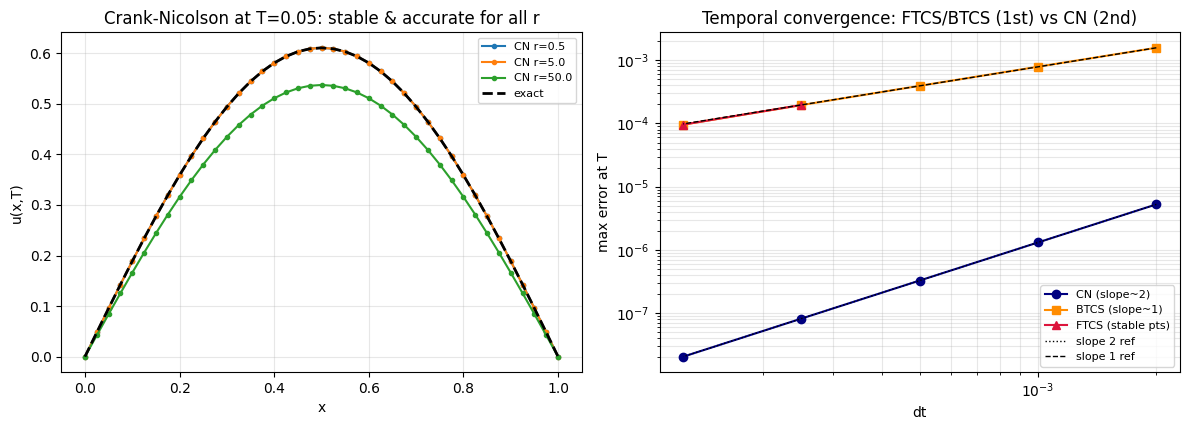

In [5]:
# --- 시각화: (좌) CN 해 vs 정확해, (우) 세 방법의 dt-수렴 log-log ---
fig, ax = plt.subplots(1, 2, figsize=(12, 4.4))

for r in [0.5, 5.0, 50.0]:
    dt = r*(1.0/M)**2/alpha
    xx, uu, _, _ = step_solver(M, dt, T, 'cn')
    ax[0].plot(xx, uu, "o-", ms=3, label=f"CN r={r}")
ax[0].plot(x_c, exact(x_c, T), "k--", lw=2, label="exact")
ax[0].set_xlabel("x"); ax[0].set_ylabel("u(x,T)")
ax[0].set_title(f"Crank-Nicolson at T={T}: stable & accurate for all r")
ax[0].legend(fontsize=8); ax[0].grid(alpha=.3)

cb = conv.dropna(subset=["err_BTCS"])
ax[1].loglog(conv["dt"], conv["err_CN"], "o-", color="navy", label="CN (slope~2)")
ax[1].loglog(cb["dt"], cb["err_BTCS"], "s-", color="darkorange", label="BTCS (slope~1)")
ff = conv.dropna(subset=["err_FTCS"])
if len(ff) >= 2:
    ax[1].loglog(ff["dt"], ff["err_FTCS"], "^-", color="crimson", label="FTCS (stable pts)")
d = conv["dt"].values
ax[1].loglog(d, conv["err_CN"].values[0]*(d/d[0])**2, "k:", lw=1, label="slope 2 ref")
ax[1].loglog(d, conv["err_BTCS"].values[0]*(d/d[0])**1, "k--", lw=1, label="slope 1 ref")
ax[1].set_xlabel("dt"); ax[1].set_ylabel("max error at T")
ax[1].set_title("Temporal convergence: FTCS/BTCS (1st) vs CN (2nd)")
ax[1].legend(fontsize=8); ax[1].grid(alpha=.3, which="both")
plt.tight_layout(); plt.show()

## 4. 결과 해석

1. **무조건 안정**: CN 은 $r=0.5,5,50$ 어디서도 정확해에 붙으며 발산하지 않는다 — 증폭인자 $|\xi|=|(1-2s)/(1+2s)|\le1$ ($s=r\sin^2\ge0$)이 보장.
2. **시간 2차**: *공간오차를 상쇄* 하려고 각 방법을 같은 격자($M=40$)에서 아주 작은 $\Delta t_{\text{ref}}$ 로 수렴시킨 자기 자신을 기준해로 삼아 비교했다(정확해와 비교하면 공간 절단오차가 바닥을 만들어 차수가 안 보인다). 그 결과 CN 의 시간오차는 log-log 기울기 **$\approx 2$**, BTCS·FTCS 는 **$\approx 1$** 로 또렷이 갈린다 — 이론과 일치. (FTCS 는 $r\le\tfrac12$ 안에서만 측정; 넘으면 불안정이라 NaN.)
3. **원인**: CN 은 시간방향 사다리꼴 적분이라 $\mathcal{O}(\Delta t^2)$, 양·음함수는 직사각형 적분이라 $\mathcal{O}(\Delta t)$. 같은 정확도를 얻는 데 CN 은 훨씬 적은 시간스텝이면 충분하다.
4. **한계**: CN 은 매우 큰 $r$ 에서 $\xi\to-1$ 이라 초기 불연속·급경사 데이터에서 비물리적 톱니 진동이 남을 수 있다(여기 매끄러운 IC 에서는 안 보임). 실무에선 첫 몇 스텝을 BTCS 로 *완충(Rannacher)* 하기도 한다.

> **결론**: Crank–Nicolson 은 *무조건 안정 + 시간 2차* 로 §12.1 포물형 문제의 표준 해법이다 — 양함수의 단순함도 음함수의 안정성도 넘어선다.

**§12.1 마무리 / 다음 절 예고**: 같은 *격자+삼중대각* 사고는 Chapter 12 의 다음 절들로 확장된다 — **§12.2 쌍곡형(파동방정식, CFL 조건)**, **§12.3 타원형(푸아송/라플라스, 2D 블록 삼중대각)**. Day 41 의 1D 삼중대각이 2D 에서 **오중대각/블록 삼중대각** 으로 커지며 다시 만난다.